# Best hyperparameters (`rand30`)

Cosmo `_p5_n10000`, `_rp`, anchor `bx=32` / `n_train=10000`. Sweeps end with `_sweep-rand30`.

For each statistics set, reads `results_sbi/sbi<tag_inf>/best_run.txt` (one line: W&B run id), written by `code/choose_best_run.py` after ranking by min validation loss and a coverage stall smoke test. Hyperparameters are taken from that run's `config.pkl` (keys in `sbi_model._WANDB_SWEEP_PARAMETER_KEYS`); validation losses are read from local `inference.p` when present.


In [2]:
import pickle
import sys
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np

from choose_best_run import build_sweep_tag_inf, sweep_root_for_tag_inf
from generate_config_inference import (
    N_TRAIN_SWEEP,
    resolve_train_tag_bundle,
    tags_mask_for_sweep,
)
from sbi_model import _WANDB_SWEEP_PARAMETER_KEYS, _read_best_run_id_from_dir_sbi


In [3]:
data_mode = "muchisimocks"
tag_params = "_p5_n10000"
tag_sweep = "-rand30"
reparameterize = True

STATISTICS_LISTS = [
    ["pk"],
    ["pk", "pgm"],
    ["pk", "bispec"],
    ["pk", "bispec", "pgm"],
]
LABELS = [
    "pk",
    "pk + pgm",
    "pk + bispec (kb0.25)",
    "pk + bispec (kb0.25) + pgm",
]


def _loss_summary_local(run_dir: Path) -> dict:
    fn = run_dir / "inference.p"
    if not fn.is_file():
        return {}
    try:
        with open(fn, "rb") as f:
            inf = pickle.load(f)
    except Exception:
        return {}
    summ = getattr(inf, "_summary", None) or {}
    tr = np.asarray(summ.get("training_loss", []), dtype=float)
    va = np.asarray(summ.get("validation_loss", []), dtype=float)
    if tr.size == 0:
        return {}
    out = {"n_epochs": len(tr), "final_training_loss": float(tr[-1])}
    if va.size:
        out["final_validation_loss"] = float(va[-1])
        out["min_validation_loss"] = float(np.min(va))
        out["min_validation_epoch"] = int(np.argmin(va)) + 1
    return out


def print_best_from_local_sweep(labels, statistics_lists, *, tag_params, tag_biasparams, tag_noise):
    for label, statistics in zip(labels, statistics_lists):
        tags_mask = tags_mask_for_sweep(statistics)
        tag_inf = build_sweep_tag_inf(
            data_mode=data_mode,
            statistics=statistics,
            tags_mask=tags_mask,
            tag_params=tag_params,
            tag_biasparams=tag_biasparams,
            tag_noise=tag_noise,
            reparameterize=reparameterize,
            tag_sweep=tag_sweep,
        )
        sweep_root = sweep_root_for_tag_inf(tag_inf)
        print("=" * 72)
        print(label)
        print(f"  tag_inf={tag_inf}")
        print(f"  sweep_root={sweep_root}")
        try:
            run_id = _read_best_run_id_from_dir_sbi(str(sweep_root))
        except (FileNotFoundError, ValueError) as e:
            print(f"  (!) {e}")
            print()
            continue
        run_dir = sweep_root / run_id
        cfg_path = run_dir / "config.pkl"
        if not cfg_path.is_file():
            print(f"  (!) missing {cfg_path}")
            print()
            continue
        with open(cfg_path, "rb") as f:
            cfg = pickle.load(f)
        if not isinstance(cfg, dict):
            print(f"  (!) config.pkl: expected dict, got {type(cfg).__name__}")
            print()
            continue
        raw = {k: v for k, v in cfg.items() if not str(k).startswith("_")}
        missing = [k for k in _WANDB_SWEEP_PARAMETER_KEYS if raw.get(k) is None]
        if missing:
            try:
                import wandb

                api = wandb.Api()
                run = api.run(f"{api.default_entity}/muchisimocks-sbi/{run_id}")
                raw = {
                    k: v
                    for k, v in dict(run.config).items()
                    if not str(k).startswith("_")
                }
                missing = [k for k in _WANDB_SWEEP_PARAMETER_KEYS if raw.get(k) is None]
            except Exception:
                pass
        if missing:
            print(f"  (!) missing sweep hyperparameters {missing}")
            print(f"      config.pkl keys: {sorted(raw.keys())}")
            print(
                "      repair: python code/fix_wandb_metrics.py --write-config-pkl ..."
            )
            print()
            continue
        print(f"  best_run.txt -> {run_id}")
        ls = _loss_summary_local(run_dir)
        if ls:
            print(f"  min_validation_loss (local inference.p)={ls.get('min_validation_loss')}")
            print(f"  final_validation_loss={ls.get('final_validation_loss')}")
        for k in _WANDB_SWEEP_PARAMETER_KEYS:
            print(f"  {k}: {raw[k]}")
        print()


for noise_mode in ("noiseless", "noisy"):
    print("#" * 72)
    print(noise_mode)
    print()
    t = resolve_train_tag_bundle(tag_params, noise_mode)
    print_best_from_local_sweep(
        LABELS,
        STATISTICS_LISTS,
        tag_params=t["tag_params"],
        tag_biasparams=t["tag_biasparams"],
        tag_noise=t["tag_noise"],
    )


########################################################################
noiseless

pk
  tag_inf=_muchisimocks_pk_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_sweep-rand30
  sweep_root=/scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_sweep-rand30
  best_run.txt -> sheby1lo
  min_validation_loss (local inference.p)=-8.207770845413208
  final_validation_loss=-8.068879843711853
  learning_rate: 0.0003
  hidden_features: 128
  training_batch_size: 64
  num_transforms: 10

pk + pgm
  tag_inf=_muchisimocks_pk_pgm_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_sweep-rand30
  sweep_root=/scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_sweep-rand30
  best_run.txt -> z2eab8rm
  min_validation_loss (local inference.p)=-14.857696254730225
  final_validation_loss=-14.707515504837037
  learning_rate: 0.0001
  hidden_features: 256
  training_batch

# Inference results (`best-rand30`)

Fiducial training: `bx=32`, `n_train=10000`, inference loads checkpoints under `results_sbi/sbi<...>_best-rand30` (best hyperparameters from the `rand30` sweeps above). Same test scenarios as `2026-03-12_inference.ipynb`: mean fixed cosmology, coverage set, SHAMe OOD mock — extended to four statistics combinations (pk; pk + pgm; pk + bispec kb0.25; pk + bispec kb0.25 + pgm).

In [5]:
import sys
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

import plotter
import data_loader
import generate_params as genp
import utils_plot
import utils_inference

%load_ext autoreload
%autoreload 2

In [6]:
# Shared configuration (matches 2026-03-12_inference + four statistics sets + best sweep checkpoint)
bx = 32
n_train = 10000
TAG_INF_BEST_SUFFIX = "_best-rand30"  # run_mode `best` with tag_sweep `-rand30`

data_mode = "muchisimocks"
TAG_PARAMS_TRAIN = "_p5_n10000"
TAG_BIASPARAMS_TRAIN = "_biasnest_p4_n320000"
TAG_BIASPARAMS_TRAIN_NOISY = "_biasnoisenest_p9_n320000"
TAG_NOISE_TRAIN = "_noise_unit_p5_n10000"

tag_reparam = "_rp"
statistics_arr = [["pk"], ["pk", "pgm"], ["pk", "bispec"], ["pk", "bispec", "pgm"]]
tags_mask_inf = ["", "", "_kb0.25", "_kb0.25"]
tag_stats_arr = [f'_{"_".join(s)}' for s in statistics_arr]

extents = {**genp.get_bounds("cosmo"), **genp.get_bounds("bias")}

TAG_PARAMS_TEST_FIXED = "_shame_p0_n1000"
TAG_BIASPARAMS_TEST_FIXED = "_biasshame_p0_n1"

TAG_PARAMS_TEST_COV = "_coverage_p5_n1000"
TAG_BIASPARAMS_TEST_COV = "_biascoverage_p4_n1000"
TAG_BIASPARAMS_TEST_COV_NOISY = "_biasnoisecoverage_p9_n1000"
TAG_NOISE_TEST_COV = "_noise_unit_coverage_p5_n1000"

DATA_MODE_TEST_SHAME = "shame"
TAG_MOCK_SHAME = "_nbar0.00022"

idx_obs = 0

# Noiseless inference

In [24]:
tags_inf_noiseless, labels_noiseless, colors_noiseless, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode,
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN,
    statistics_arr=statistics_arr,
    bx=bx,
    tag_noise=None,
    tag_reparam=tag_reparam,
    n_train=n_train,
    tags_mask=tags_mask_inf,
)
tags_inf_noiseless = [t + TAG_INF_BEST_SUFFIX for t in tags_inf_noiseless]

cosmo_param_names_vary, bias_param_names_vary, param_names_vary = utils_plot.load_training_params(
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN,
    bx=bx,
)

param_names_contour = ["omega_cold", "sigma8_cold"] + bias_param_names_vary
inf_methods_noiseless = ["sbi"] * len(tags_inf_noiseless)

## Mean of fixed cosmology (`shame_p0_n1000`)

In [29]:
tags_test_fixed_mean = utils_plot.setup_test_tags(
    data_mode=data_mode,
    tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED,
    tag_stats_arr=tag_stats_arr,
    tag_noise_test=None,
    tag_datagen_test="_mean",
    tags_mask_test=tags_mask_inf,
)

theta_test_fixed = data_loader.load_theta_test(
    TAG_PARAMS_TEST_FIXED,
    TAG_BIASPARAMS_TEST_FIXED,
    cosmo_param_names_vary=cosmo_param_names_vary,
    bias_param_names_vary=bias_param_names_vary,
)

theta_obs_true = theta_test_fixed[idx_obs] if theta_test_fixed.ndim == 2 else theta_test_fixed
idxs_contour = [param_names_vary.index(pn) for pn in param_names_contour]
theta_obs_true_show = theta_obs_true[idxs_contour]


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy


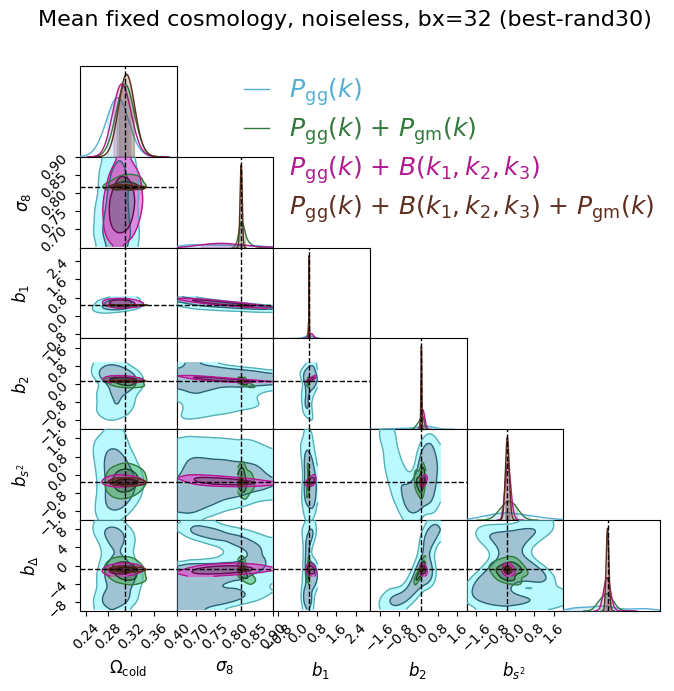

In [30]:
plotter.plot_contours_inf(
    param_names=param_names_contour,
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show,
    inf_methods=inf_methods_noiseless,
    tags_inf=tags_inf_noiseless,
    tags_test=tags_test_fixed_mean,
    colors=colors_noiseless,
    labels=labels_noiseless,
    title=f"Mean fixed cosmology, noiseless, bx={bx} (best-rand30)",
    extents=extents,
    unreparameterize=True,
)


## Coverage test set

In [27]:
tags_test_cov = utils_plot.setup_test_tags(
    data_mode=data_mode,
    tag_params_test=TAG_PARAMS_TEST_COV,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_COV,
    tag_stats_arr=tag_stats_arr,
    tag_noise_test=TAG_NOISE_TEST_COV,
    tag_datagen_test="",
    tags_mask_test=tags_mask_inf,
)

theta_cov = data_loader.load_theta_test(
    TAG_PARAMS_TEST_COV,
    TAG_BIASPARAMS_TEST_COV,
    cosmo_param_names_vary=cosmo_param_names_vary,
    bias_param_names_vary=bias_param_names_vary,
)

theta_obs_true = theta_cov[idx_obs] if theta_cov.ndim == 2 else theta_cov
idxs_contour = [param_names_vary.index(pn) for pn in param_names_contour]
theta_obs_true_show = theta_obs_true[idxs_contour]

fn_samples_test_pred = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_coverage_p5_n1000_biascoverage_p4_n1000_pred.npy


fn_samples_test_pred = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_coverage_p5_n1000_biascoverage_p4_n1000_pred.npy
fn_samples_test_pred = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_coverage_p5_n1000_biascoverage_p4_n1000_pred.npy
fn_samples_test_pred = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_coverage_p5_n1000_biascoverage_p4_n1000_pred.npy


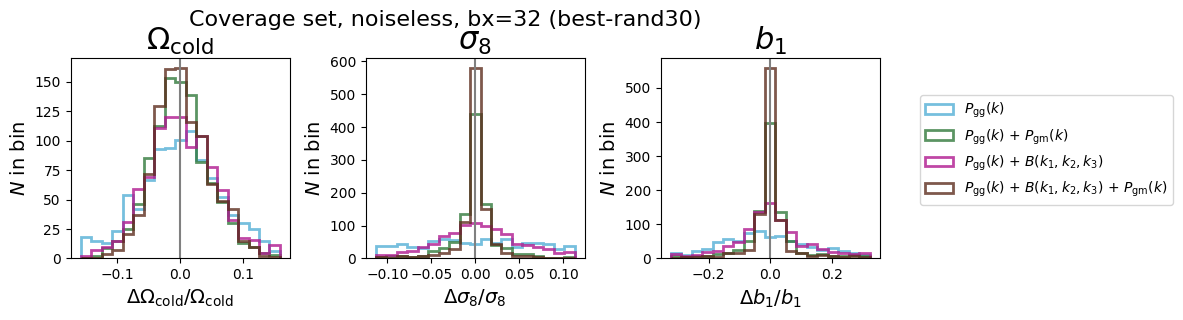

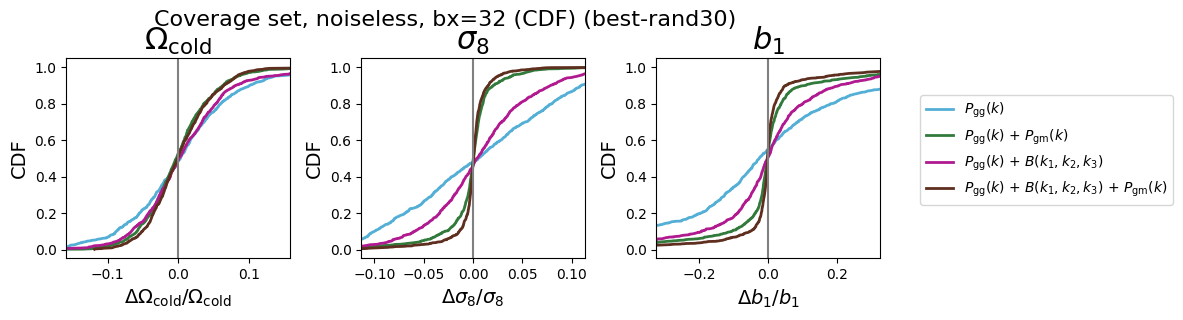

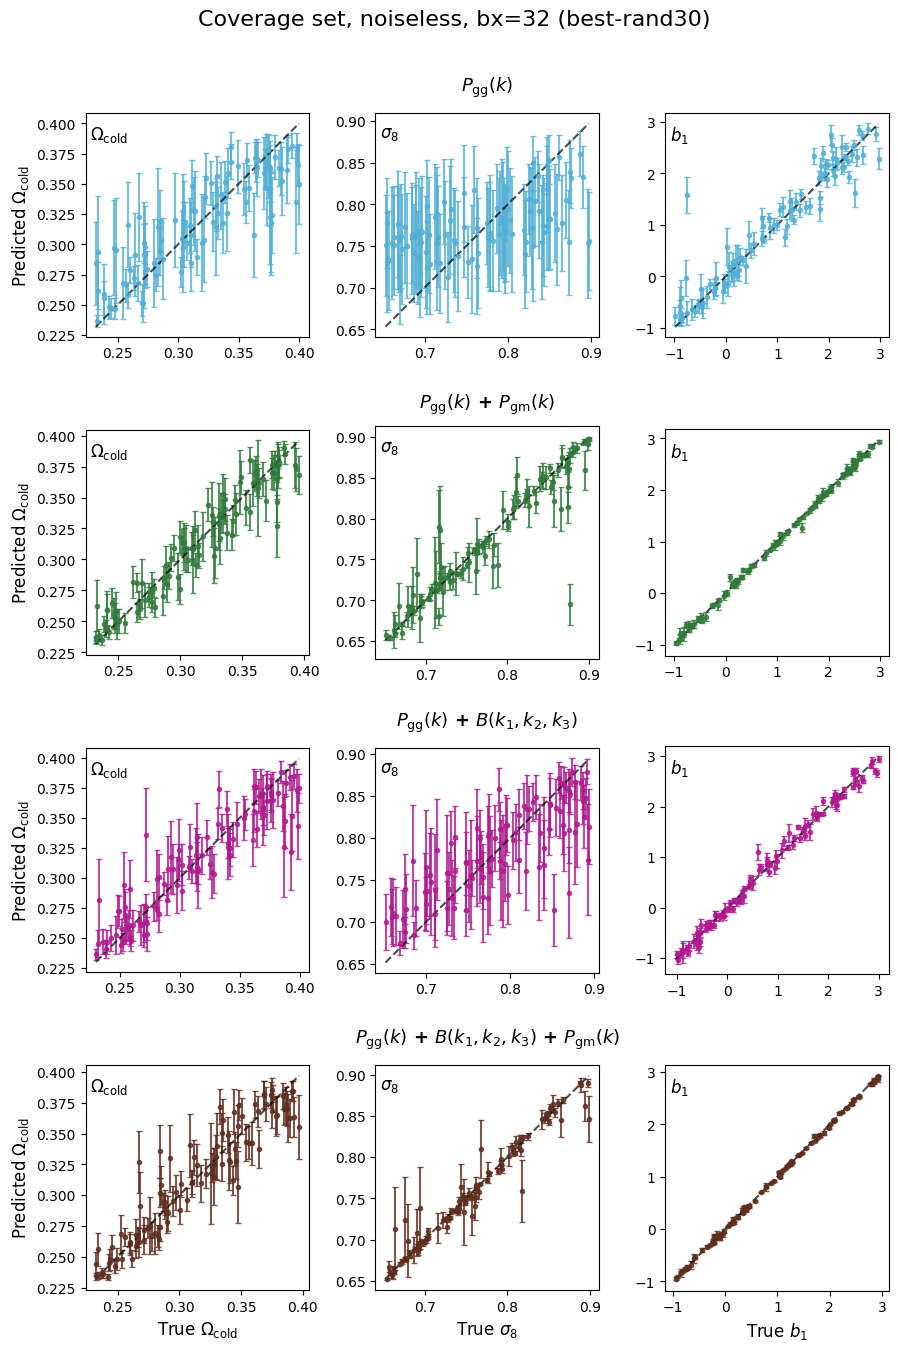

(<Figure size 900x1400 with 12 Axes>,
 array([[<Axes: ylabel='Predicted $\\Omega_\\mathrm{cold}$'>, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='Predicted $\\Omega_\\mathrm{cold}$'>, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='Predicted $\\Omega_\\mathrm{cold}$'>, <Axes: >,
         <Axes: >],
        [<Axes: xlabel='True $\\Omega_\\mathrm{cold}$', ylabel='Predicted $\\Omega_\\mathrm{cold}$'>,
         <Axes: xlabel='True $\\sigma_{8}$'>, <Axes: xlabel='True $b_1$'>]],
       dtype=object))

In [28]:
# Coverage set: non-contour distribution + comparison plots (unreparameterized key params)
param_names_key, param_names_key_rp = utils_plot.get_param_names_key()

tags_test_cov_noiseless = utils_plot.setup_test_tags(
    data_mode=data_mode,
    tag_params_test=TAG_PARAMS_TEST_COV,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_COV,
    tag_stats_arr=tag_stats_arr,
    tag_noise_test=None,
    tag_datagen_test="",
    tags_mask_test=tags_mask_inf,
)

theta_true_arr, theta_pred_arr, vars_pred_arr, covs_pred_arr, _ = utils_plot.load_test_predictions(
    tags_inf=tags_inf_noiseless,
    tags_data_test=tags_test_cov_noiseless,
    tag_params_test=TAG_PARAMS_TEST_COV,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_COV,
    cosmo_param_names_vary=cosmo_param_names_vary,
    bias_param_names_vary=bias_param_names_vary,
    param_names_vary=param_names_vary,
    tag_reparam=tag_reparam,
    param_names_show=param_names_key_rp,
)

plotter.plot_dists_mean_subplots(
    theta_pred_arr,
    theta_true_arr,
    param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_noiseless,
    label_arr=labels_noiseless,
    n_bins=20,
    alpha=0.8,
    histtype="step",
    xlim_auto=False,
    plot_cdf=False,
    unreparameterize=True,
    title=f"Coverage set, noiseless, bx={bx} (best-rand30)",
)

plotter.plot_dists_mean_subplots(
    theta_pred_arr,
    theta_true_arr,
    param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_noiseless,
    label_arr=labels_noiseless,
    n_bins=20,
    alpha=0.8,
    histtype="step",
    xlim_auto=False,
    plot_cdf=True,
    unreparameterize=True,
    title=f"Coverage set, noiseless, bx={bx} (CDF) (best-rand30)",
)

plotter.plot_comp_mean_subplots_grid(
    statistics_arr,
    theta_pred_arr,
    theta_true_arr,
    covs_pred_arr,
    param_names=param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_noiseless,
    label_arr=labels_noiseless,
    alpha=0.8,
    N_plot=100,
    unreparameterize=True,
    title=f"Coverage set, noiseless, bx={bx} (best-rand30)",
)

## SHAMe mock

In [13]:
tag_stats_shame = [f'_{"_".join(s)}' + "".join(m) for s, m in zip(statistics_arr, tags_mask_inf)]

tags_test_shame = utils_plot.setup_shame_mock_test_tags(
    tag_stats_arr=tag_stats_shame,
    data_mode_test=DATA_MODE_TEST_SHAME,
    tag_mock=TAG_MOCK_SHAME,
)

theta_ood = data_loader.load_theta_ood(
    DATA_MODE_TEST_SHAME,
    TAG_MOCK_SHAME,
    cosmo_param_names_vary=cosmo_param_names_vary,
    bias_param_names_vary=bias_param_names_vary,
)

theta_obs_true = theta_ood[idx_obs] if theta_ood.ndim == 2 else theta_ood
idxs_contour = [param_names_vary.index(pn) for pn in param_names_contour]
theta_obs_true_show = theta_obs_true[idxs_contour]


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
ERROR: missing samples (inf_method=sbi, tag_inf=_muchisimocks_pk_pgm_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30, tag_test=_shame_pk_pgm_nbar0.00022): /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy


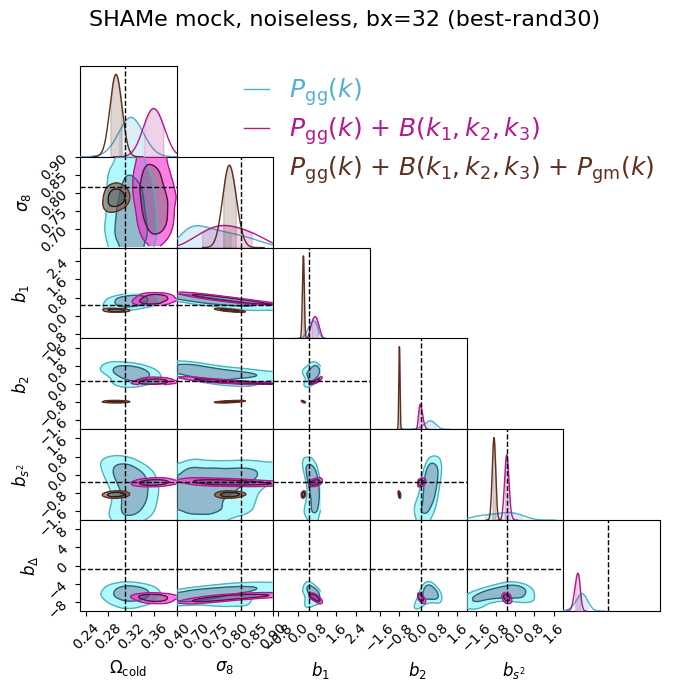

In [14]:
plotter.plot_contours_inf(
    param_names=param_names_contour,
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show,
    inf_methods=inf_methods_noiseless,
    tags_inf=tags_inf_noiseless,
    tags_test=tags_test_shame,
    colors=colors_noiseless,
    labels=labels_noiseless,
    title=f"SHAMe mock, noiseless, bx={bx} (best-rand30)",
    extents=extents,
    unreparameterize=True,
)


# Noisy inference

In [7]:
tags_inf_noisy, labels_noisy, colors_noisy, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode,
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN_NOISY,
    statistics_arr=statistics_arr,
    bx=bx,
    tag_noise=TAG_NOISE_TRAIN,
    tag_reparam=tag_reparam,
    n_train=n_train,
    tags_mask=tags_mask_inf,
)
tags_inf_noisy = [t + TAG_INF_BEST_SUFFIX for t in tags_inf_noisy]

cosmo_param_names_vary_n, bias_param_names_vary_n, param_names_vary_n = utils_plot.load_training_params(
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN_NOISY,
    bx=bx,
)

param_names_contour_n = ["omega_cold", "sigma8_cold"] + bias_param_names_vary_n
inf_methods_noisy = ["sbi"] * len(tags_inf_noisy)


## Mean of fixed cosmology (`shame_p0_n1000`)

In [16]:
tags_test_fixed_mean = utils_plot.setup_test_tags(
    data_mode=data_mode,
    tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED,
    tag_stats_arr=tag_stats_arr,
    tag_noise_test=None,
    tag_datagen_test="_mean",
    tags_mask_test=tags_mask_inf,
)

theta_test_fixed = data_loader.load_theta_test(
    TAG_PARAMS_TEST_FIXED,
    TAG_BIASPARAMS_TEST_FIXED,
    cosmo_param_names_vary=cosmo_param_names_vary_n,
    bias_param_names_vary=bias_param_names_vary_n,
)

theta_obs_true = theta_test_fixed[idx_obs] if theta_test_fixed.ndim == 2 else theta_test_fixed
idxs_contour = [param_names_vary_n.index(pn) for pn in param_names_contour_n]
theta_obs_true_show = theta_obs_true[idxs_contour]


In [17]:
plotter.plot_contours_inf(
    param_names=param_names_contour_n,
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show,
    inf_methods=inf_methods_noisy,
    tags_inf=tags_inf_noisy,
    tags_test=tags_test_fixed_mean,
    colors=colors_noisy,
    labels=labels_noisy,
    title=f"Mean fixed cosmology, noisy, bx={bx} (best-rand30)",
    extents=extents,
    unreparameterize=True,
)


ERROR: missing samples (inf_method=sbi, tag_inf=_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30, tag_test=_muchisimocks_pk_shame_p0_n1000_biasshame_p0_n1_mean): /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
ERROR: missing samples (inf_method=sbi, tag_inf=_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30, tag_test=_muchisimocks_pk_pgm_shame_p0_n1000_biasshame_p0_n1_mean): /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
ERROR: missing samples (inf_method=sbi, tag_inf=_muchisimocks_pk_bispec_kb0.25_p5_

## Coverage test set

In [19]:
tags_test_cov = utils_plot.setup_test_tags(
    data_mode=data_mode,
    tag_params_test=TAG_PARAMS_TEST_COV,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_COV_NOISY,
    tag_stats_arr=tag_stats_arr,
    tag_noise_test=TAG_NOISE_TEST_COV,
    tag_datagen_test="",
    tags_mask_test=tags_mask_inf,
)

theta_cov = data_loader.load_theta_test(
    TAG_PARAMS_TEST_COV,
    TAG_BIASPARAMS_TEST_COV_NOISY,
    cosmo_param_names_vary=cosmo_param_names_vary_n,
    bias_param_names_vary=bias_param_names_vary_n,
)

theta_obs_true = theta_cov[idx_obs] if theta_cov.ndim == 2 else theta_cov
idxs_contour = [param_names_vary_n.index(pn) for pn in param_names_contour_n]
theta_obs_true_show = theta_obs_true[idxs_contour]

fn_samples_test_pred = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000_pred.npy


fn_samples_test_pred = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000_pred.npy
fn_samples_test_pred = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000_pred.npy
fn_samples_test_pred = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000_pred.npy


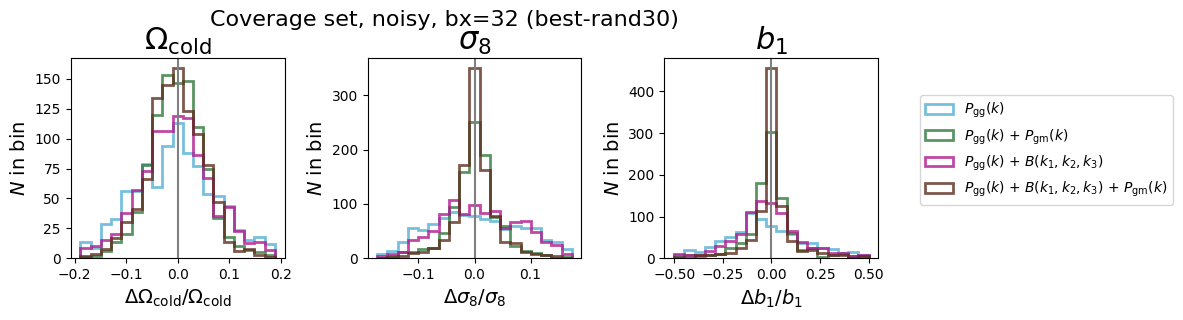

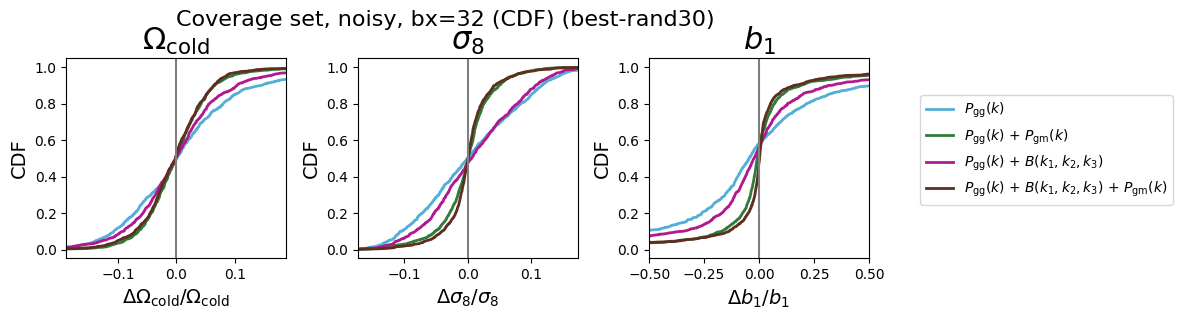

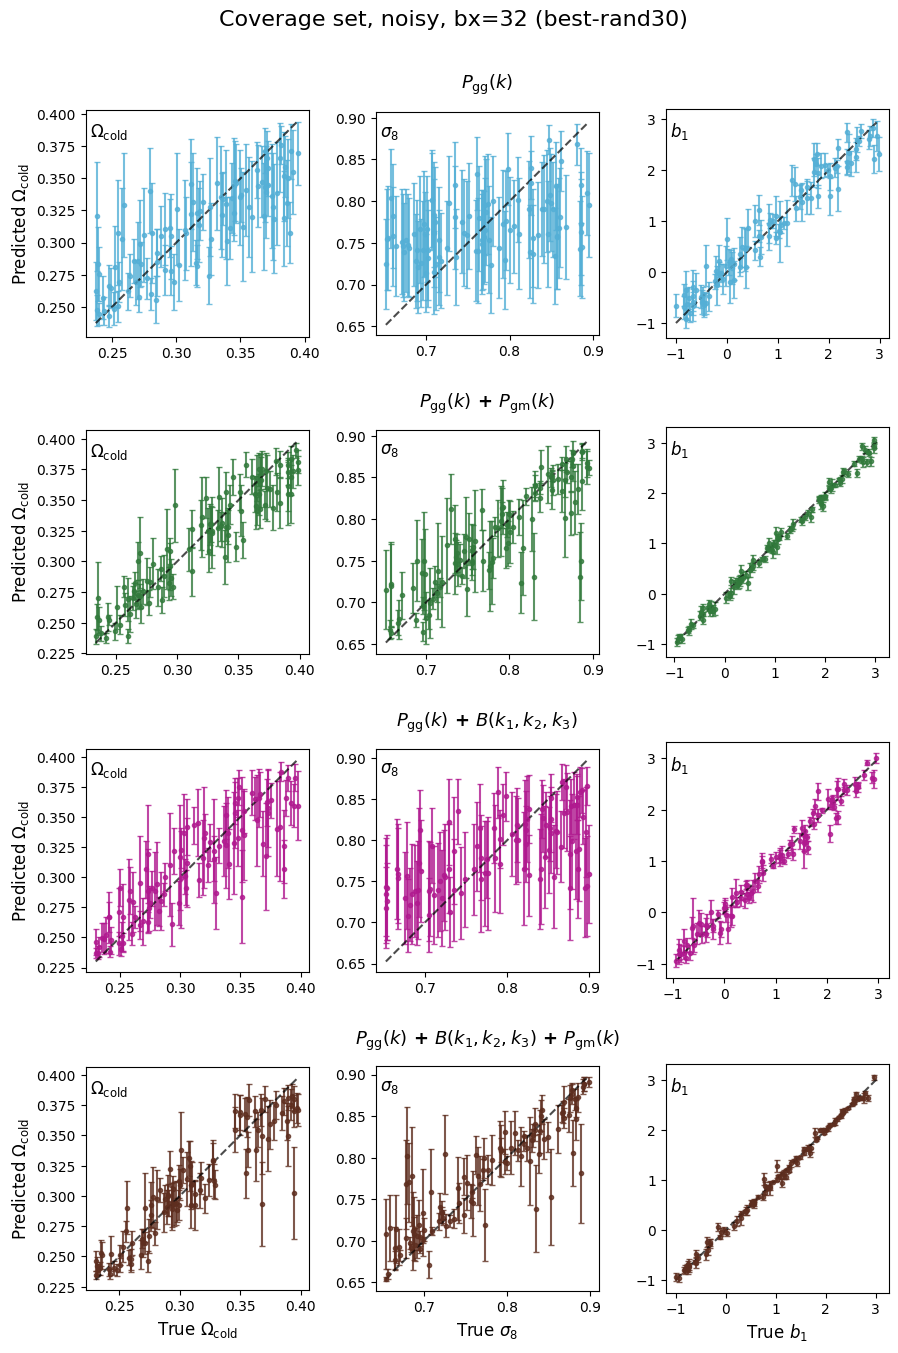

(<Figure size 900x1400 with 12 Axes>,
 array([[<Axes: ylabel='Predicted $\\Omega_\\mathrm{cold}$'>, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='Predicted $\\Omega_\\mathrm{cold}$'>, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='Predicted $\\Omega_\\mathrm{cold}$'>, <Axes: >,
         <Axes: >],
        [<Axes: xlabel='True $\\Omega_\\mathrm{cold}$', ylabel='Predicted $\\Omega_\\mathrm{cold}$'>,
         <Axes: xlabel='True $\\sigma_{8}$'>, <Axes: xlabel='True $b_1$'>]],
       dtype=object))

In [20]:
param_names_key, param_names_key_rp = utils_plot.get_param_names_key()

theta_true_arr, theta_pred_arr, vars_pred_arr, covs_pred_arr, _ = utils_plot.load_test_predictions(
    tags_inf=tags_inf_noisy,
    tags_data_test=tags_test_cov,
    tag_params_test=TAG_PARAMS_TEST_COV,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_COV_NOISY,
    cosmo_param_names_vary=cosmo_param_names_vary_n,
    bias_param_names_vary=bias_param_names_vary_n,
    param_names_vary=param_names_vary_n,
    tag_reparam=tag_reparam,
    param_names_show=param_names_key_rp,
)

plotter.plot_dists_mean_subplots(
    theta_pred_arr,
    theta_true_arr,
    param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_noisy,
    label_arr=labels_noisy,
    n_bins=20,
    alpha=0.8,
    histtype="step",
    xlim_auto=False,
    plot_cdf=False,
    unreparameterize=True,
    title=f"Coverage set, noisy, bx={bx} (best-rand30)",
)

plotter.plot_dists_mean_subplots(
    theta_pred_arr,
    theta_true_arr,
    param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_noisy,
    label_arr=labels_noisy,
    n_bins=20,
    alpha=0.8,
    histtype="step",
    xlim_auto=False,
    plot_cdf=True,
    unreparameterize=True,
    title=f"Coverage set, noisy, bx={bx} (CDF) (best-rand30)",
)

plotter.plot_comp_mean_subplots_grid(
    statistics_arr,
    theta_pred_arr,
    theta_true_arr,
    covs_pred_arr,
    param_names=param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_noisy,
    label_arr=labels_noisy,
    alpha=0.8,
    N_plot=100,
    unreparameterize=True,
    title=f"Coverage set, noisy, bx={bx} (best-rand30)",
)


## SHAMe mock

In [8]:
tag_stats_shame = [f'_{"_".join(s)}' + "".join(m) for s, m in zip(statistics_arr, tags_mask_inf)]

tags_test_shame = utils_plot.setup_shame_mock_test_tags(
    tag_stats_arr=tag_stats_shame,
    data_mode_test=DATA_MODE_TEST_SHAME,
    tag_mock=TAG_MOCK_SHAME,
)

theta_ood = data_loader.load_theta_ood(
    DATA_MODE_TEST_SHAME,
    TAG_MOCK_SHAME,
    cosmo_param_names_vary=cosmo_param_names_vary_n,
    bias_param_names_vary=bias_param_names_vary_n,
)

theta_obs_true = theta_ood[idx_obs] if theta_ood.ndim == 2 else theta_ood
idxs_contour = [param_names_vary_n.index(pn) for pn in param_names_contour_n]
theta_obs_true_show = theta_obs_true[idxs_contour]

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy


Parameter An_bs2 in chain $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$ is not constrained


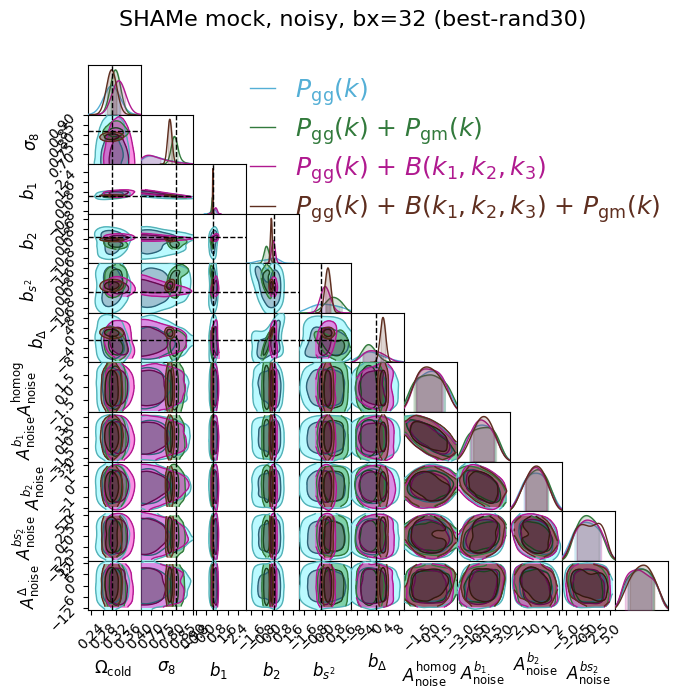

In [17]:
plotter.plot_contours_inf(
    param_names=param_names_contour_n,
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show,
    inf_methods=inf_methods_noisy,
    tags_inf=tags_inf_noisy,
    tags_test=tags_test_shame,
    colors=colors_noisy,
    labels=labels_noisy,
    title=f"SHAMe mock, noisy, bx={bx} (best-rand30)",
    extents=extents,
    unreparameterize=True,
)


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.2_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.2_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2_kpgm0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.2_kpgm0.2_nbar0.00022_pred.npy


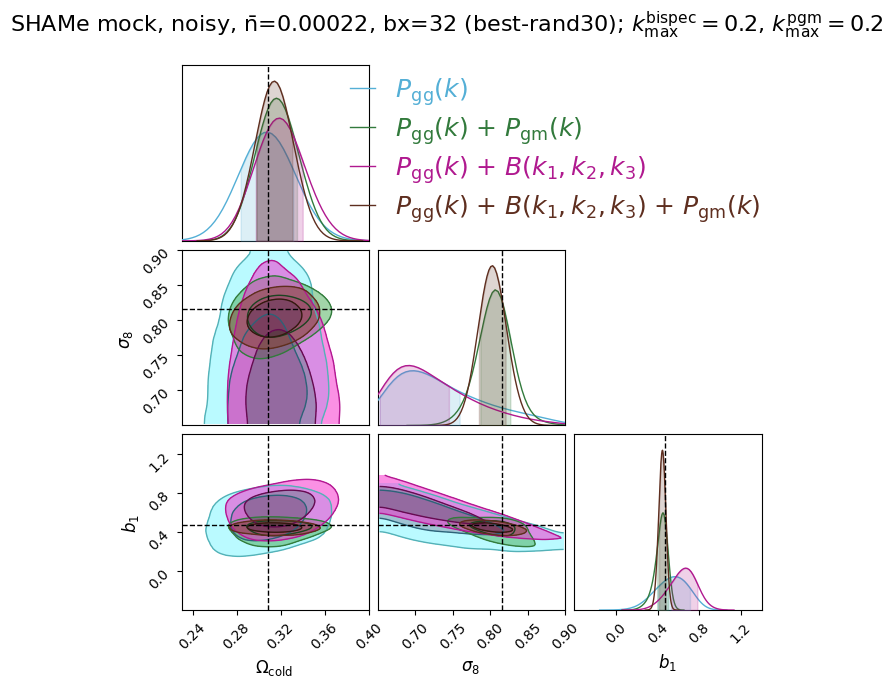

In [ ]:
tags_mask_inf_n022 = ["", "_kpgm0.2", "_kb0.2", "_kb0.2_kpgm0.2"]

tags_inf_n022, labels_n022, colors_n022, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode,
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN_NOISY,
    statistics_arr=statistics_arr,
    bx=bx,
    tag_noise=TAG_NOISE_TRAIN,
    tag_reparam=tag_reparam,
    n_train=n_train,
    tags_mask=tags_mask_inf_n022,
)
tags_inf_n022 = [t + TAG_INF_BEST_SUFFIX for t in tags_inf_n022]

tag_stats_shame_n022 = [
    f'_{"_".join(s)}' + "".join(m) for s, m in zip(statistics_arr, tags_mask_inf_n022)
]
tag_mock_n022 = "_nbar0.00022"
tags_test_shame_n022 = utils_plot.setup_shame_mock_test_tags(
    tag_stats_arr=tag_stats_shame_n022,
    data_mode_test=DATA_MODE_TEST_SHAME,
    tag_mock=tag_mock_n022,
)

theta_ood_n022 = data_loader.load_theta_ood(
    DATA_MODE_TEST_SHAME,
    tag_mock_n022,
    cosmo_param_names_vary=cosmo_param_names_vary_n,
    bias_param_names_vary=bias_param_names_vary_n,
)
theta_obs_true_n022 = theta_ood_n022[idx_obs] if theta_ood_n022.ndim == 2 else theta_ood_n022
idxs_zoom_n022 = [param_names_vary_n.index(pn) for pn in PARAM_NAMES_ZOOM]
theta_obs_true_show_n022 = theta_obs_true_n022[idxs_zoom_n022]

title_n022 = (
    f"SHAMe mock, noisy, n̄=0.00022, bx={bx} (best-rand30); "
    f"{utils_plot.get_mask_label('_kb0.2')}, {utils_plot.get_mask_label('_kpgm0.2')}"
)

plotter.plot_contours_inf(
    param_names=PARAM_NAMES_ZOOM,
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show_n022,
    inf_methods=["sbi"] * len(tags_inf_n022),
    tags_inf=tags_inf_n022,
    tags_test=tags_test_shame_n022,
    colors=colors_n022,
    labels=labels_n022,
    title=title_n022,
    extents=extents_mid,
    unreparameterize=True,
)

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy


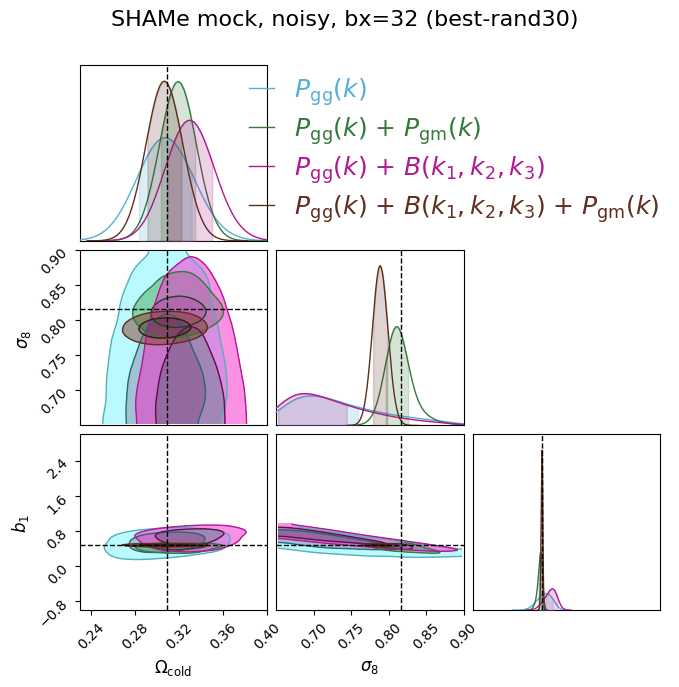

In [18]:
plotter.plot_contours_inf(
    param_names=['omega_cold', 'sigma8_cold', 'b1'],
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show,
    inf_methods=inf_methods_noisy,
    tags_inf=tags_inf_noisy,
    tags_test=tags_test_shame,
    colors=colors_noisy,
    labels=labels_noisy,
    title=f"SHAMe mock, noisy, bx={bx} (best-rand30)",
    extents=extents,
    unreparameterize=True,
)


### dependence on bispec max

#### pk+bispec+pgm

In [68]:

tags_mask_kb = ["_kb0.15", "_kb0.2", "_kb0.25", "_kb0.3", "_kb0.35", "_kb0.4"]
statistics_arr_kb = [['pk', 'bispec', 'pgm']]*len(tags_mask_kb)
tags_mask_kb = [""] + tags_mask_kb
statistics_arr_kb = [['pk', 'pgm']] + statistics_arr_kb

tags_inf_kb, labels, colors, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode,    
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN_NOISY,
    statistics_arr=statistics_arr_kb,
    bx=bx,
    tag_noise=TAG_NOISE_TRAIN,
    tag_reparam=tag_reparam,
    n_train=n_train,
    tags_mask=tags_mask_kb,
)
tags_inf_kb = [t + TAG_INF_BEST_SUFFIX for t in tags_inf_kb]
inf_methods_kb = ["sbi"] * len(tags_inf_kb)

#tag_stats_shame_kb = [f'_{"_".join(s)}' + "".join(m) for s, m in zip(statistics_arr_kb, tags_mask_kb)]
tag_stats_shame_kb = [f'_{"_".join(s)}' for s in statistics_arr_kb]

tags_test_shame_kb = utils_plot.setup_shame_mock_test_tags(
    tag_stats_arr=tag_stats_shame_kb,
    data_mode_test=DATA_MODE_TEST_SHAME,
    tag_mock=TAG_MOCK_SHAME,
    tags_mask=tags_mask_kb,
)

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.15_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.15_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.2_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/ksto

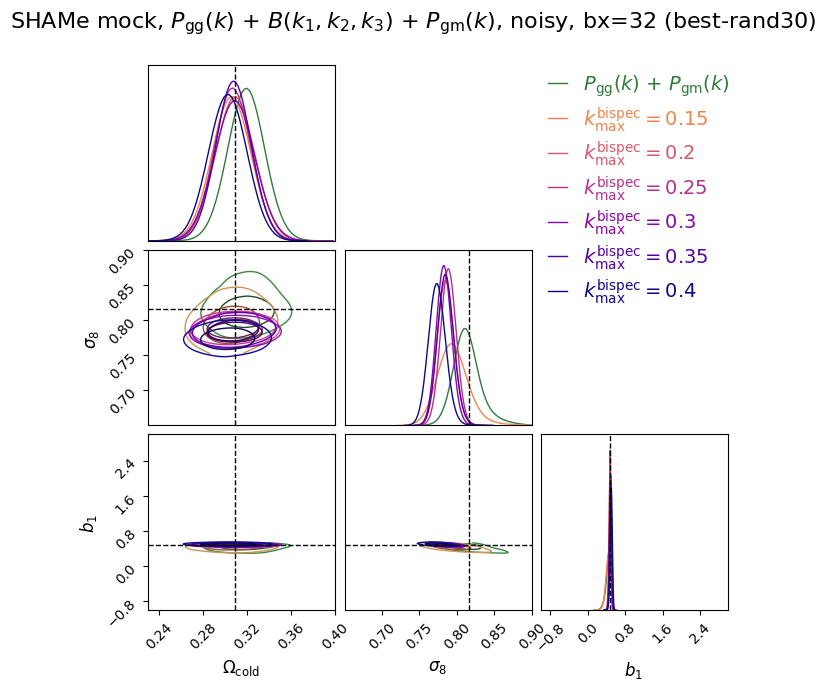

In [69]:
labels_kb = [utils_plot.get_mask_label(tag_mask) for tag_mask in tags_mask_kb[1:]]
cmap = plt.get_cmap("plasma_r")  # or plt.cm.viridis
colors_kb = cmap(np.linspace(0.3, 1.0, len(tags_mask_kb[1:])))

labels_kb = [labels[0]] + labels_kb
#colors_kb = [colors[0]] + colors_kb
#colors_kb = [str(colors[0])] + list(np.asarray(colors_kb).astype(str))
colors_kb = [colors[0]] + list(colors_kb)

plotter.plot_contours_inf(
    param_names=['omega_cold', 'sigma8_cold', 'b1'],
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show,
    inf_methods=inf_methods_kb,
    tags_inf=tags_inf_kb,
    tags_test=tags_test_shame_kb,
    colors=colors_kb,
    labels=labels_kb,
    title=f"SHAMe mock, {labels[-1]}, noisy, bx={bx} (best-rand30)",
    extents=extents,
    unreparameterize=True,
    fontsize_legend=14
)

In [70]:
extents_narrow = extents.copy()
extents_narrow['b1'] = [0.2,0.7]
extents_narrow['sigma8_cold'] = [0.7, 0.9]

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.15_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.15_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.2_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/ksto

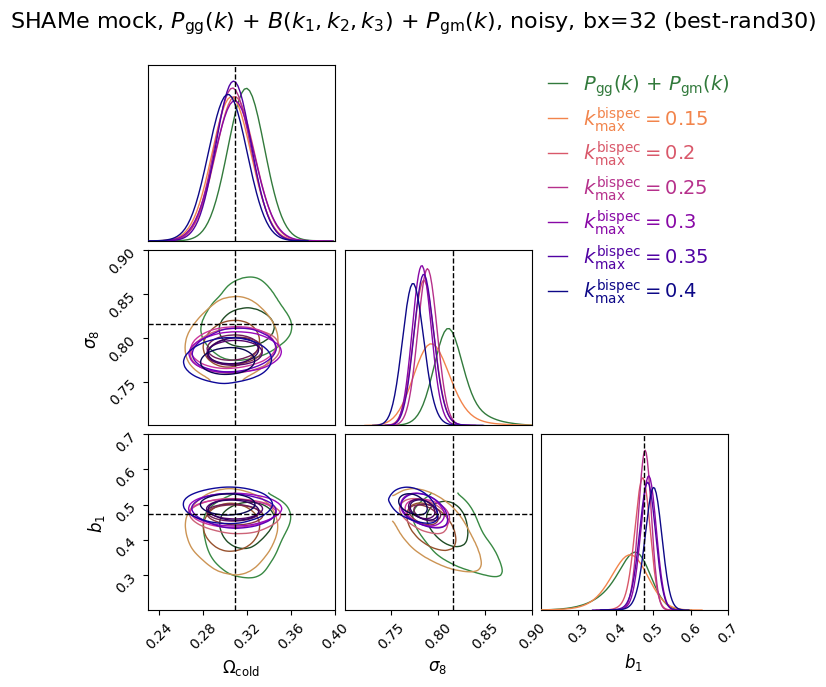

In [72]:
plotter.plot_contours_inf(
    param_names=['omega_cold', 'sigma8_cold', 'b1'],
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show,
    inf_methods=inf_methods_kb,
    tags_inf=tags_inf_kb,
    tags_test=tags_test_shame_kb,
    colors=colors_kb,
    labels=labels_kb,
    title=f"SHAMe mock, {labels[-1]}, noisy, bx={bx} (best-rand30)",
    extents=extents_narrow,
    unreparameterize=True,
    fontsize_legend=14
)

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.15_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.15_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.2_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/ksto

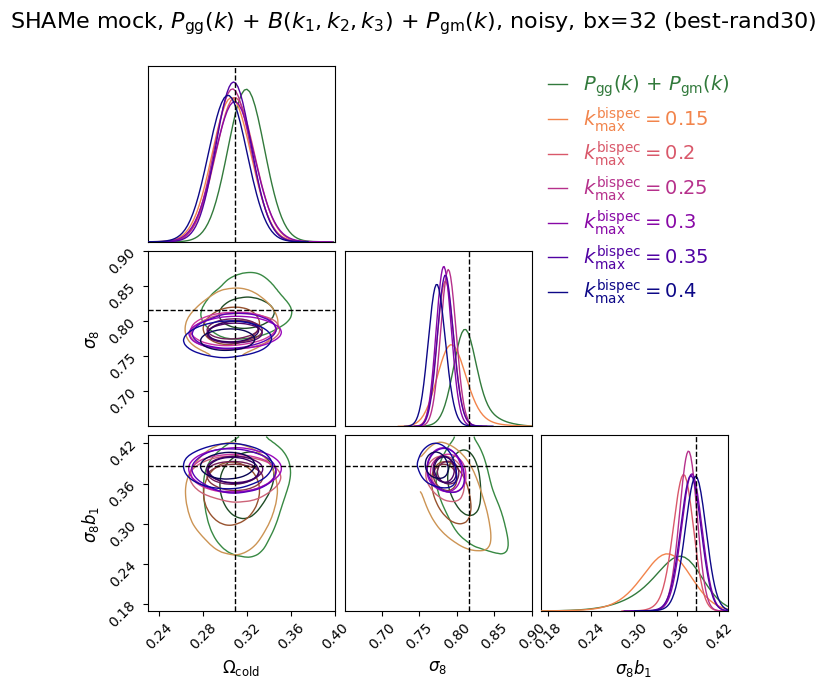

In [73]:
plotter.plot_contours_inf(
    param_names=['omega_cold', 'sigma8_cold', 'b1'],
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show,
    inf_methods=inf_methods_kb,
    tags_inf=tags_inf_kb,
    tags_test=tags_test_shame_kb,
    colors=colors_kb,
    labels=labels_kb,
    title=f"SHAMe mock, {labels[-1]}, noisy, bx={bx} (best-rand30)",
    extents=extents,
    unreparameterize=False,
    fontsize_legend=14
)

#### pk+bispec (no pgm)

In [65]:

tags_mask_kb = ["_kb0.15", "_kb0.2", "_kb0.25", "_kb0.3", "_kb0.35", "_kb0.4"]
statistics_arr_kb = [['pk', 'bispec']]*len(tags_mask_kb)
tags_inf_kb, labels, colors, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode,    
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN_NOISY,
    statistics_arr=statistics_arr_kb,
    bx=bx,
    tag_noise=TAG_NOISE_TRAIN,
    tag_reparam=tag_reparam,
    n_train=n_train,
    tags_mask=tags_mask_kb,
)
tags_inf_kb = [t + TAG_INF_BEST_SUFFIX for t in tags_inf_kb]
inf_methods_kb = ["sbi"] * len(tags_inf_kb)

#tag_stats_shame_kb = [f'_{"_".join(s)}' + "".join(m) for s, m in zip(statistics_arr_kb, tags_mask_kb)]
tag_stats_shame_kb = [f'_{"_".join(s)}' for s in statistics_arr_kb]

tags_test_shame_kb = utils_plot.setup_shame_mock_test_tags(
    tag_stats_arr=tag_stats_shame_kb,
    data_mode_test=DATA_MODE_TEST_SHAME,
    tag_mock=TAG_MOCK_SHAME,
    tags_mask=tags_mask_kb,
)

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.15_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.15_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.2_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.3_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.3_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/m

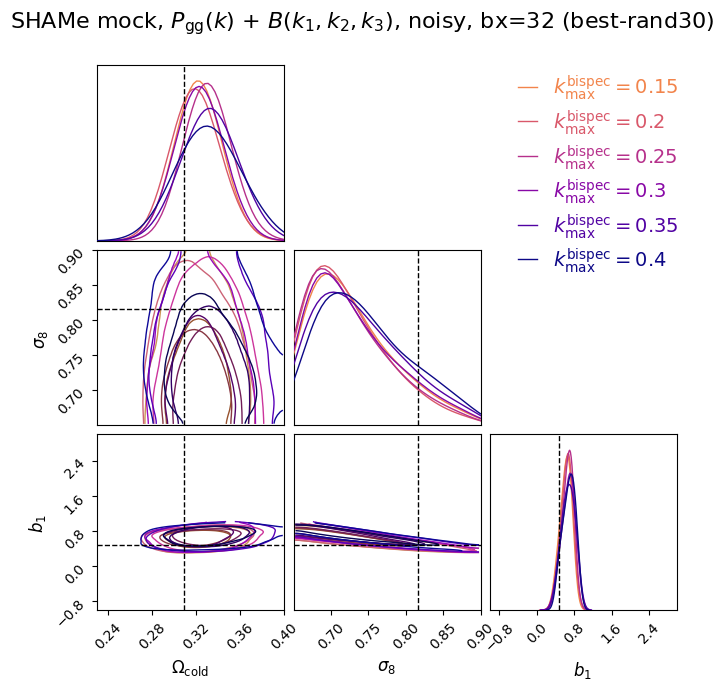

In [66]:
labels_kb = [utils_plot.get_mask_label(tag_mask) if tag_mask else label for label, tag_mask in zip(labels, tags_mask_kb)]
cmap = plt.get_cmap("plasma_r")  # or plt.cm.viridis
colors_kb = cmap(np.linspace(0.3, 1.0, len(tags_mask_kb))) 

plotter.plot_contours_inf(
    param_names=['omega_cold', 'sigma8_cold', 'b1'],
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show,
    inf_methods=inf_methods_kb,
    tags_inf=tags_inf_kb,
    tags_test=tags_test_shame_kb,
    colors=colors_kb,
    labels=labels_kb,
    title=f"SHAMe mock, {labels[0]}, noisy, bx={bx} (best-rand30)",
    extents=extents,
    unreparameterize=True,
    fontsize_legend=14
)

In [67]:
# Example: posterior summaries for pk + pgm, noisy SHAMe mock (same index pattern as 2026-03-12_inference)
inf_method = "sbi"
idx_stats = statistics_arr.index(["pk", "pgm"])
tag_inf = tags_inf_noisy[idx_stats]
tag_test = tags_test_shame[idx_stats]
median, p16, p84, param_names = utils_inference.get_chain_statistics(
    idx_obs, inf_method, tag_inf, tag_test=tag_test, unreparameterize=True
)

for i, param_name in enumerate(param_names):
    print(f"{param_name}: {median[i]:.4f} [{p16[i]:.4f}, {p84[i]:.4f}]")

ERROR: missing samples (inf_method=sbi, tag_inf=_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30, tag_test=_shame_pk_pgm_nbar0.00022): /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
